In [1]:
!pip install ipython-sql
%load_ext sql

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 41.4 MB/s eta 0:00:00


In [2]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# 1. Download the correct Chinook SQLite database
!wget https://raw.githubusercontent.com/lerocha/chinook-database/master/ChinookDatabase/DataSources/Chinook_Sqlite.sqlite -O chinook.db

# Connect the Chinook Database
conn = sqlite3.connect("chinook.db")

--2026-07-29 14:10:23--  https://raw.githubusercontent.com/lerocha/chinook-database/master/ChinookDatabase/DataSources/Chinook_Sqlite.sqlite
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1007616 (984K) [application/octet-stream]
Saving to: ‘chinook.db’

chinook.db          100%[===================>] 984.00K  --.-KB/s    in 0.06s   

2026-07-29 14:10:23 (16.8 MB/s) - ‘chinook.db’ saved [1007616/1007616]



In [4]:
pd.read_sql("""
SELECT g.Name, COUNT(*) AS TrackCount
FROM Track t
JOIN Genre g ON t.GenreId = g.GenreId
GROUP BY g.Name
ORDER BY TrackCount DESC
LIMIT 10;
""", conn)

,Name,TrackCount
0,Rock,1297
1,Latin,579
2,Metal,374
3,Alternative & Punk,332
4,Jazz,130
5,TV Shows,93
6,Blues,81
7,Classical,74
8,Drama,64
9,R&B/Soul,61


In [5]:
pd.read_sql("""
SELECT BillingCountry, SUM(Total) AS Revenue
FROM Invoice
GROUP BY BillingCountry
ORDER BY Revenue DESC
LIMIT 10;
""", conn)

,BillingCountry,Revenue
0,USA,523.06
1,Canada,303.96
2,France,195.10
3,Brazil,190.10
4,Germany,156.48
5,United Kingdom,112.86
6,Czech Republic,90.24
7,Portugal,77.24
8,India,75.26
9,Chile,46.62


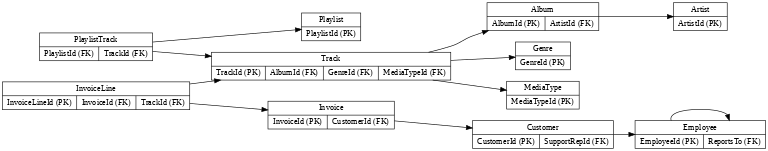

In [6]:
from graphviz import Digraph
from IPython.display import Image

# Create ERD
dot = Digraph(comment="Chinook Database ERD", format='png')
dot.attr(rankdir='LR', size='8')

# Define tables (simplified: only PK/FK)
tables = {
    "Artist": ["ArtistId (PK)"],
    "Album": ["AlbumId (PK)", "ArtistId (FK)"],
    "Track": ["TrackId (PK)", "AlbumId (FK)", "GenreId (FK)", "MediaTypeId (FK)"],
    "Genre": ["GenreId (PK)"],
    "MediaType": ["MediaTypeId (PK)"],
    "Playlist": ["PlaylistId (PK)"],
    "PlaylistTrack": ["PlaylistId (FK)", "TrackId (FK)"],
    "Customer": ["CustomerId (PK)", "SupportRepId (FK)"],
    "Invoice": ["InvoiceId (PK)", "CustomerId (FK)"],
    "InvoiceLine": ["InvoiceLineId (PK)", "InvoiceId (FK)", "TrackId (FK)"],
    "Employee": ["EmployeeId (PK)", "ReportsTo (FK)"]
}

# Add nodes
for table, cols in tables.items():
    label = f"{table}|{{" + "|".join(cols) + "}}"
    dot.node(table, label=label, shape="record")

# Add relationships
relationships = [
    ("Album", "Artist"),
    ("Track", "Album"),
    ("Track", "Genre"),
    ("Track", "MediaType"),
    ("PlaylistTrack", "Playlist"),
    ("PlaylistTrack", "Track"),
    ("Invoice", "Customer"),
    ("InvoiceLine", "Invoice"),
    ("InvoiceLine", "Track"),
    ("Customer", "Employee"),
    ("Employee", "Employee")  # manager hierarchy
]

for child, parent in relationships:
    dot.edge(child, parent)

# Save and display
dot.render("chinook_erd", format="png", cleanup=True)
Image(filename="chinook_erd.png")

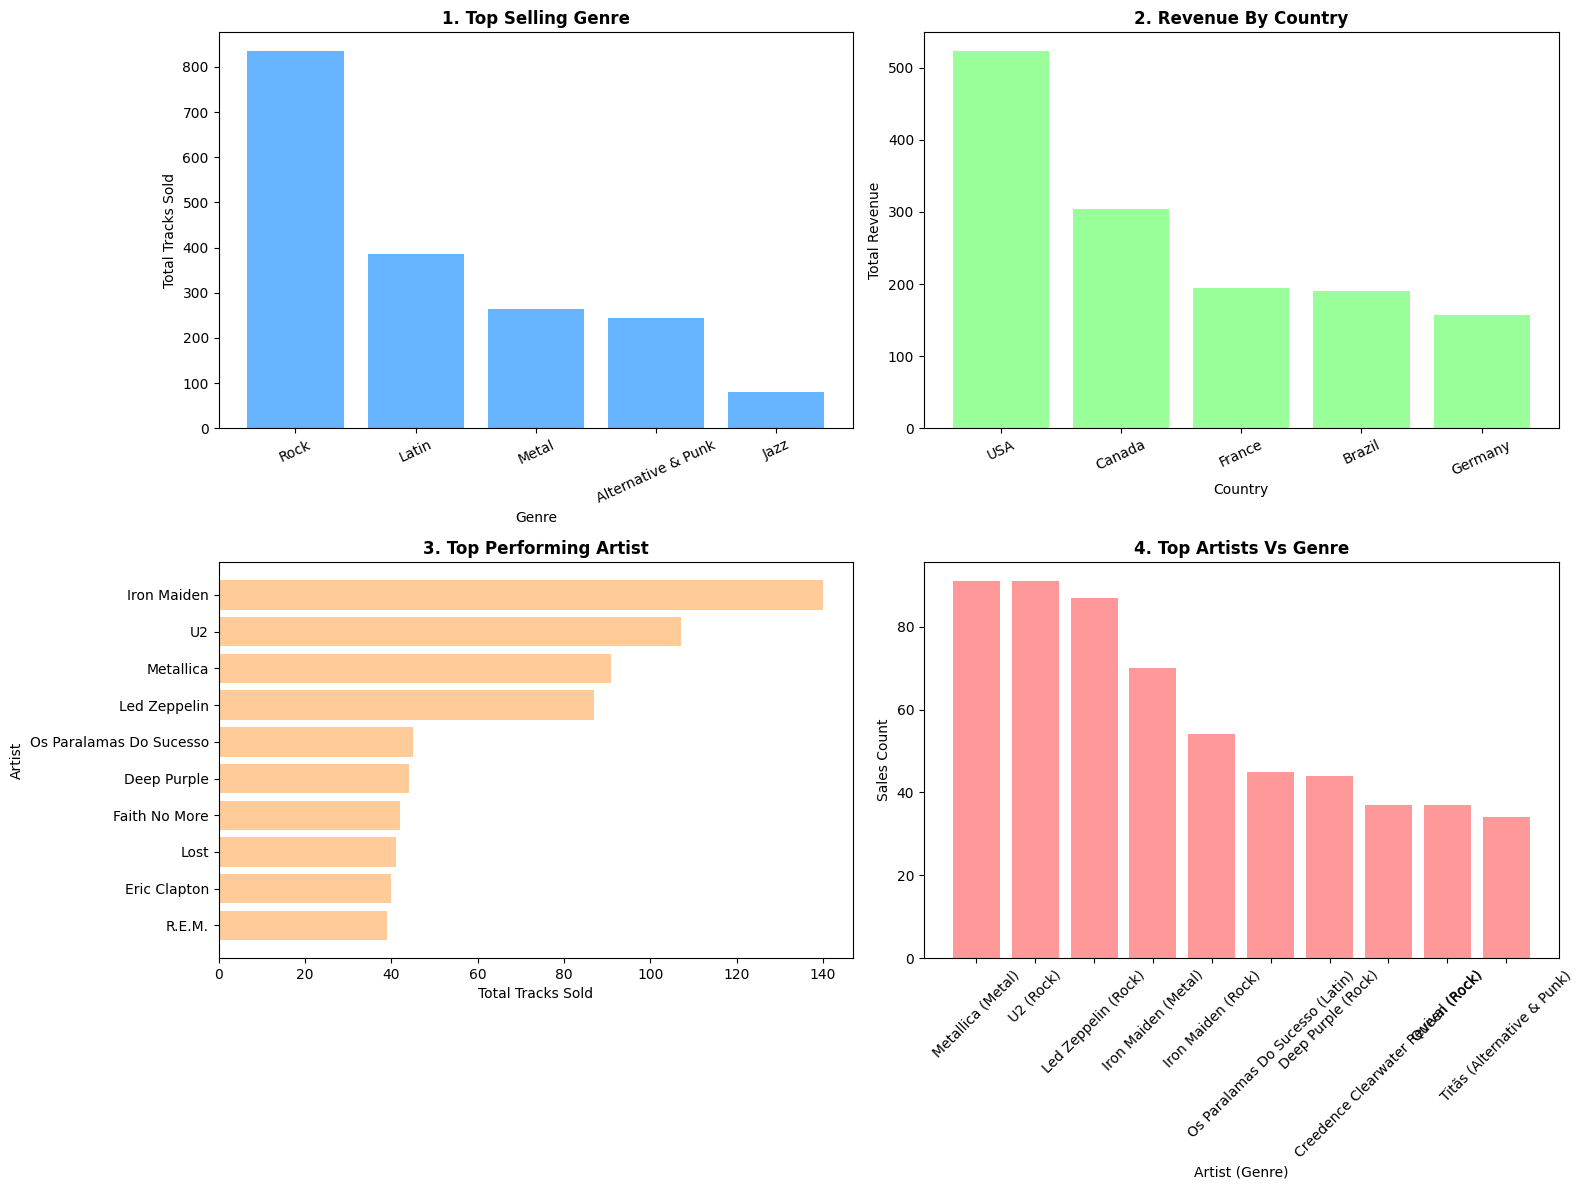

In [9]:
!pip install sqlite-utils > /dev/null
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import urllib.request

url = "https://raw.githubusercontent.com/lerocha/chinook-database/master/ChinookDatabase/DataSources/Chinook_Sqlite.sqlite"
urllib.request.urlretrieve(url, "chinook.db")

conn = sqlite3.connect('chinook.db')

# 1. Top Selling Genre
query_1 = """
    SELECT g.Name AS GenreName, SUM(il.Quantity) AS TotalTracksSold
    FROM Genre g
    JOIN Track t ON g.GenreId = t.GenreId
    JOIN InvoiceLine il ON t.TrackId = il.TrackId
    GROUP BY g.Name
    ORDER BY TotalTracksSold DESC
    LIMIT 5;
"""
df_1 = pd.read_sql(query_1, conn)

# 2. Revenue By Country
query_2 = """
    SELECT BillingCountry AS Country, SUM(Total) AS TotalRevenue
    FROM Invoice
    GROUP BY BillingCountry
    ORDER BY TotalRevenue DESC
    LIMIT 5;
"""
df_2 = pd.read_sql(query_2, conn)

# 3. Top Performing Artist
query_3 = """
    SELECT ar.Name AS ArtistName, SUM(il.Quantity) AS TotalTracksSold
    FROM Artist ar
    JOIN Album al ON ar.ArtistId = al.ArtistId
    JOIN Track t ON al.AlbumId = t.AlbumId
    JOIN InvoiceLine il ON t.TrackId = il.TrackId
    GROUP BY ar.Name
    ORDER BY TotalTracksSold DESC
    LIMIT 10;
"""
df_3 = pd.read_sql(query_3, conn)

# 4. Top 10 Artists Vs Genre (Top artist per genre or similar relationship)
query_4 = """
    SELECT ar.Name AS ArtistName, g.Name AS GenreName, COUNT(il.InvoiceLineId) AS SalesCount
    FROM Artist ar
    JOIN Album al ON ar.ArtistId = al.ArtistId
    JOIN Track t ON al.AlbumId = t.AlbumId
    JOIN Genre g ON t.GenreId = g.GenreId
    JOIN InvoiceLine il ON t.TrackId = il.TrackId
    GROUP BY ar.Name, g.Name
    ORDER BY SalesCount DESC
    LIMIT 10;
"""
df_4 = pd.read_sql(query_4, conn)

conn.close()

# Plotting all 4 figures
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Figure 1
axes[0, 0].bar(df_1['GenreName'], df_1['TotalTracksSold'], color='#66b3ff')
axes[0, 0].set_title('1. Top Selling Genre', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Genre')
axes[0, 0].set_ylabel('Total Tracks Sold')
axes[0, 0].tick_params(axis='x', rotation=25)

# Figure 2
axes[0, 1].bar(df_2['Country'], df_2['TotalRevenue'], color='#99ff99')
axes[0, 1].set_title('2. Revenue By Country', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Country')
axes[0, 1].set_ylabel('Total Revenue')
axes[0, 1].tick_params(axis='x', rotation=25)

# Figure 3
axes[1, 0].barh(df_3['ArtistName'][::-1], df_3['TotalTracksSold'][::-1], color='#ffcc99')
axes[1, 0].set_title('3. Top Performing Artist', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Total Tracks Sold')
axes[1, 0].set_ylabel('Artist')

# Figure 4
axes[1, 1].bar(df_4['ArtistName'] + ' (' + df_4['GenreName'] + ')', df_4['SalesCount'], color='#ff9999')
axes[1, 1].set_title('4. Top Artists Vs Genre', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Artist (Genre)')
axes[1, 1].set_ylabel('Sales Count')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()